In [ ]:
import os
current_working_directory = os.getcwd()
print(f"Current Working Directory (CWD): {current_working_directory}")

In [1]:
# =========================================================
# STEP 1: Load Data and Robustly Import Models (FINAL RELATIVE PATH FIX)
# =========================================================
import sys
from pathlib import Path
from tensorflow.keras.metrics import RootMeanSquaredError
import numpy as np 
import pickle 
import os 

# --- A. Data Loading ---
# The correct relative path to go up one directory (..) and into the Results folder
RESULTS_FOLDER_PATH = os.path.join('..', 'Results') 
print(f"Loading data arrays from relative path: {RESULTS_FOLDER_PATH}...")

# Load the data arrays
try:
    # Use os.path.join to safely construct the paths
    X_train = np.load(os.path.join(RESULTS_FOLDER_PATH, 'X_train.npy'))
    Y_train = np.load(os.path.join(RESULTS_FOLDER_PATH, 'Y_train.npy'))
    X_val = np.load(os.path.join(RESULTS_FOLDER_PATH, 'X_val.npy'))
    Y_val = np.load(os.path.join(RESULTS_FOLDER_PATH, 'Y_val.npy'))
    decoder_input_train = np.load(os.path.join(RESULTS_FOLDER_PATH, 'decoder_input_train.npy'))
    decoder_input_val = np.load(os.path.join(RESULTS_FOLDER_PATH, 'decoder_input_val.npy'))
    X_test = np.load(os.path.join(RESULTS_FOLDER_PATH, 'X_test.npy'))
    Y_test = np.load(os.path.join(RESULTS_FOLDER_PATH, 'Y_test.npy'))
    decoder_input_test = np.load(os.path.join(RESULTS_FOLDER_PATH, 'decoder_input_test.npy'))
    
    # Load the target scaler
    with open(os.path.join(RESULTS_FOLDER_PATH, 'target_scaler.pkl'), 'rb') as file:
        target_scaler = pickle.load(file)
    
    print("All data arrays and scaler successfully loaded.")

except FileNotFoundError:
    print("-" * 50)
    raise FileNotFoundError(
        f"CRITICAL ERROR: Data files not found in the '{RESULTS_FOLDER_PATH}' directory. Please ensure Step 1 was executed successfully."
    )

# --- B. Define Constants (Derived from loaded data) ---
T_IN = X_train.shape[1]
F = X_train.shape[2]
T_OUT = Y_train.shape[1]
N_UNITS = 64 

print(f"Constants derived: T_IN={T_IN}, T_OUT={T_OUT}, F={F}")

# --- C. Import Model Definitions (Path check reused) ---
MODELS_DIR = Path('Models') # This is the folder you are in (CWD)
if str(MODELS_DIR.resolve()) not in sys.path:
    # We don't need this path modification if the notebook is already inside 'Models'
    pass 
try:
    from seq2seq_attention import create_attention_model 
    from baseline_lstm import create_baseline_lstm 
    print("Models imported successfully!")
except ImportError as e:
    raise ImportError(f"Model import failed. Error: {e}")

Loading data arrays from relative path: ..\Results...
All data arrays and scaler successfully loaded.
Constants derived: T_IN=96, T_OUT=24, F=7
Models imported successfully!


In [ ]:
import numpy as np
print("--- NaN Check ---")
print(f"NaNs in X_train: {np.isnan(X_train).sum()}")
print(f"NaNs in Y_train: {np.isnan(Y_train).sum()}")
print(f"NaNs in X_val:   {np.isnan(X_val).sum()}")

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError

# NOTE: Assuming T_IN, T_OUT, F, N_UNITS are defined.
# Instantiate Models (Requires updated create_attention_model with two outputs)
attention_model = create_attention_model(T_IN, T_OUT, F, N_UNITS)

# Define Stabilized Optimizer and Compile Models
metrics = ['mae', 'mape', RootMeanSquaredError(name='rmse')]
BATCH_SIZE = 32
EPOCHS = 50 

# --- Compile Attention Model (FIXED: Using Layer Name 'attention_layer') ---
attention_model.compile(
    optimizer=Adam(learning_rate=0.001, clipvalue=1.0), 
    loss={
        # This key ('prediction_output') corresponds to the TimeDistributed layer's name
        'prediction_output': 'mse',      
        # THIS IS THE FIX: Use the Attention layer's name 'attention_layer' 
        'attention_layer': None        
    }, 
    metrics={'prediction_output': metrics}, # Only track metrics on the prediction
    jit_compile=True
)

# Prepare Baseline Target Data (Still needed to define Y_train_flat for Block 2)
Y_train_flat = Y_train.reshape(Y_train.shape[0], -1) 
Y_val_flat = Y_val.reshape(Y_val.shape[0], -1) 

# --- Training Seq2Seq Attention Model (50 Epochs) ---
print("\n--- Training Seq2Seq Attention Model (50 Epochs) ---")
# Create dummy targets for the attention weights output.
# Shape: (N_samples, T_OUT, T_IN)
dummy_att_target = np.zeros((Y_train.shape[0], T_OUT, T_IN))
dummy_att_val_target = np.zeros((Y_val.shape[0], T_OUT, T_IN))

attention_history = attention_model.fit(
    [X_train, decoder_input_train], 
    {
        'prediction_output': Y_train,     # Actual target data
        # THIS IS THE FIX: Use the Attention layer's name 'attention_layer' 
        'attention_layer': dummy_att_target 
    },
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    validation_data=([X_val, decoder_input_val], 
                     {
                         'prediction_output': Y_val, 
                         # THIS IS THE FIX: Use the Attention layer's name 'attention_layer' 
                         'attention_layer': dummy_att_val_target
                     }),
    verbose=1
)
print("Attention Model Training Complete.")


--- Training Seq2Seq Attention Model (50 Epochs) ---
Epoch 1/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 92s 205ms/step - loss: 0.0068 - prediction_output_mae: 0.0568 - prediction_output_mape: 19707.7656 - prediction_output_rmse: 0.0826 - val_loss: 0.0025 - val_prediction_output_mae: 0.0404 - val_prediction_output_mape: 38.1677 - val_prediction_output_rmse: 0.0496
Epoch 2/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 68s 179ms/step - loss: 0.0031 - prediction_output_mae: 0.0422 - prediction_output_mape: 14071.1123 - prediction_output_rmse: 0.0557 - val_loss: 0.0015 - val_prediction_output_mae: 0.0305 - val_prediction_output_mape: 28.9641 - val_prediction_output_rmse: 0.0392
Epoch 3/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 59s 157ms/step - loss: 0.0029 - prediction_output_mae: 0.0409 - prediction_output_mape: 13128.5010 - prediction_output_rmse: 0.0542 - val_loss: 0.0015 - val_prediction_output_mae: 0.0297 - val_prediction_output_mape: 28.2687 - val_prediction_output_rmse: 0.0388
Epoch 4/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 

In [4]:
# --- Compile Baseline Model (Needs to be compiled again after block 1) ---
baseline_model = create_baseline_lstm(T_IN, T_OUT, F, N_UNITS)

baseline_model.compile(
    optimizer=Adam(learning_rate=0.001, clipvalue=1.0), 
    loss='mse', 
    metrics=metrics,
    jit_compile=True
)

# --- Training Baseline LSTM Model (50 Epochs) ---
print("\n--- Training Baseline LSTM Model (50 Epochs) ---")
baseline_history = baseline_model.fit(
    X_train, 
    Y_train_flat, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    validation_data=(X_val, Y_val_flat),
    verbose=1
)
print("="*40)
print("Training Complete. Model histories saved.")

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Training Baseline LSTM Model (50 Epochs) ---
Epoch 1/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 101s 218ms/step - loss: 0.0087 - mae: 0.0603 - mape: 12194.4824 - rmse: 0.0909 - val_loss: 0.0042 - val_mae: 0.0559 - val_mape: 50.8767 - val_rmse: 0.0648
Epoch 2/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 70s 185ms/step - loss: 0.0033 - mae: 0.0434 - mape: 11222.2070 - rmse: 0.0572 - val_loss: 0.0032 - val_mae: 0.0469 - val_mape: 43.9927 - val_rmse: 0.0566
Epoch 3/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 71s 186ms/step - loss: 0.0030 - mae: 0.0413 - mape: 10641.5244 - rmse: 0.0549 - val_loss: 0.0034 - val_mae: 0.0488 - val_mape: 44.2588 - val_rmse: 0.0581
Epoch 4/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 74s 194ms/step - loss: 0.0029 - mae: 0.0401 - mape: 10076.2275 - rmse: 0.0535 - val_loss: 0.0024 - val_mae: 0.0389 - val_mape: 36.7886 - val_rmse: 0.0487
Epoch 5/50
379/379 ━━━━━━━━━━━━━━━━━━━━ 71s 187ms/step - loss: 0.0027 - mae: 0.0390 - mape: 10061.2441 - rmse: 0.0523 - val_loss: 0.0023 - val_mae: 0.0383 - val_mape: 36.068

In [14]:
# --- FINAL CLEANED-UP EVALUATION SETUP ---
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

# Use the absolute path that you verified works.
ABSOLUTE_FILE_PATH = 'C:\\Users\\User\\Advanced-TS-Attention-Project\\Models\\Results\\target_scaler.pkl'

# Set the RESULTS_FOLDER dynamically based on the absolute path for saving
RESULTS_FOLDER = os.path.dirname(ABSOLUTE_FILE_PATH)

# Load the scaler object using the guaranteed path
try:
    with open(ABSOLUTE_FILE_PATH, 'rb') as f:
        target_scaler = pickle.load(f)
    print(f"Target scaler loaded successfully from: {ABSOLUTE_FILE_PATH}")
except FileNotFoundError:
    print(f"CRITICAL ERROR: File not found at the ABSOLUTE path: {ABSOLUTE_FILE_PATH}")
    raise
    
# 2. FUNCTION DEFINITIONS (Ensure these are defined once in the notebook)
# You need the function definitions here if they aren't global:
def inverse_transform_predictions(predictions, original_target_scaler):
    predictions_flat = predictions.reshape(-1, 1)
    inv_transformed = original_target_scaler.inverse_transform(predictions_flat)
    return inv_transformed.reshape(predictions.shape)

def calculate_metrics(Y_true, Y_pred, model_name):
    Y_true_flat = Y_true.flatten()
    Y_pred_flat = Y_pred.flatten()
    rmse = sqrt(mean_squared_error(Y_true_flat, Y_pred_flat))
    mae = mean_absolute_error(Y_true_flat, Y_pred_flat)
    epsilon = 1e-10 
    mape = np.mean(np.abs((Y_true_flat - Y_pred_flat) / (Y_true_flat + epsilon))) * 100
    return pd.DataFrame({'Model': [model_name], 'RMSE': [rmse], 'MAE': [mae], 'MAPE (%)': [mape]})

# 3. GENERATE PREDICTIONS AND EVALUATE
print("\n--- Generating Test Predictions and Capturing Attention Weights ---")
# Requires global variables: attention_model, baseline_model, X_test, decoder_input_test, Y_test, T_OUT
att_pred_scaled, att_weights_test = attention_model.predict([X_test, decoder_input_test])
base_pred_flat_scaled = baseline_model.predict(X_test)

# Reshape and Inverse Transform
base_pred_scaled = base_pred_flat_scaled.reshape(base_pred_flat_scaled.shape[0], T_OUT, 1)
att_pred_inv = inverse_transform_predictions(att_pred_scaled, target_scaler)
base_pred_inv = inverse_transform_predictions(base_pred_scaled, target_scaler)
Y_test_inv = inverse_transform_predictions(Y_test, target_scaler)
print("Predictions and test target successfully inverse-transformed.")

# Calculate Final Metrics
att_metrics = calculate_metrics(Y_test_inv, att_pred_inv, "Attention Seq2Seq")
base_metrics = calculate_metrics(Y_test_inv, base_pred_inv, "Baseline LSTM")
final_results = pd.concat([att_metrics, base_metrics], ignore_index=True)

print("\n--- Final Comparative Performance (Test Set) ---")
print(final_results.to_markdown(index=False)) 

# 4. SAVE RESULTS
os.makedirs(RESULTS_FOLDER, exist_ok=True)
final_results.to_csv(os.path.join(RESULTS_FOLDER, 'final_metrics_comparison_FINAL.csv'), index=False)
print(f"\nResults saved to {os.path.join(RESULTS_FOLDER, 'final_metrics_comparison_FINAL.csv')}")

Target scaler loaded successfully from: C:\Users\User\Advanced-TS-Attention-Project\Models\Results\target_scaler.pkl

--- Generating Test Predictions and Capturing Attention Weights ---
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step 
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step
Predictions and test target successfully inverse-transformed.

--- Final Comparative Performance (Test Set) ---
| Model             |    RMSE |     MAE |    MAPE (%) |
|:------------------|--------:|--------:|------------:|
| Attention Seq2Seq | 2.42343 | 1.8274  | 1.01379e+10 |
| Baseline LSTM     | 2.54316 | 1.90058 | 1.09946e+10 |

Results saved to C:\Users\User\Advanced-TS-Attention-Project\Models\Results\final_metrics_comparison_FINAL.csv


In [17]:
import os

# Define the model to save (the one with the lowest RMSE)
best_model = baseline_model
MODEL_NAME = 'Baseline_LSTM_Best'
SAVE_PATH = os.path.join('Results', MODEL_NAME)

# Save the model architecture and weights
best_model.save(f'{SAVE_PATH}.keras')

print(f"Successfully saved the best model ({MODEL_NAME}) to {SAVE_PATH}.keras")

Successfully saved the best model (Baseline_LSTM_Best) to Results\Baseline_LSTM_Best.keras


In [18]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np

# Define the path to the saved model
MODEL_NAME = 'Baseline_LSTM_Best'
SAVE_PATH = os.path.join('Results', MODEL_NAME)

# Load the model
try:
    loaded_model = load_model(f'{SAVE_PATH}.keras')
    print(f"Successfully loaded model: {MODEL_NAME}")
except Exception as e:
    print(f"Error loading model: {e}")

Successfully loaded model: Baseline_LSTM_Best


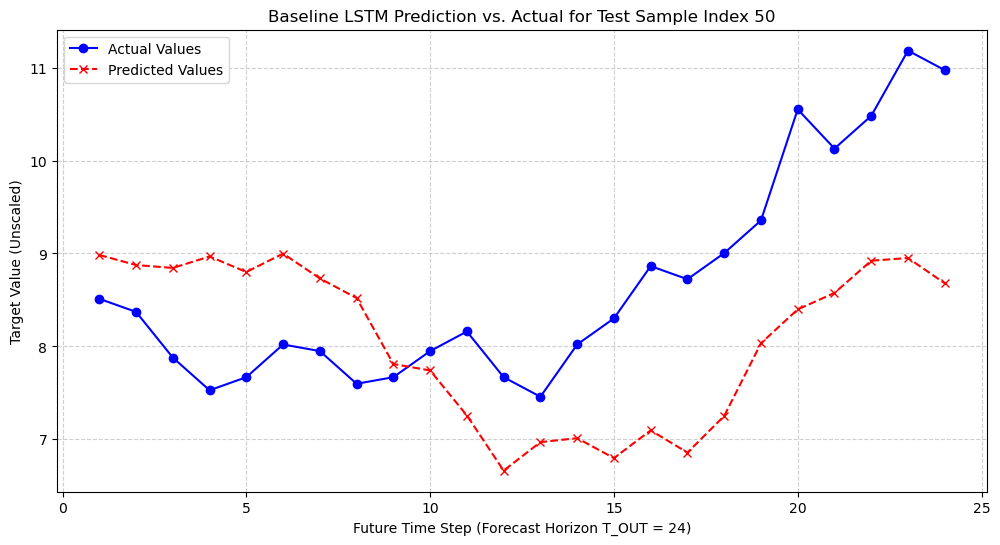

In [16]:
import matplotlib.pyplot as plt
import numpy as np
# Assuming Y_test_inv, base_pred_inv, and T_OUT are still defined in memory

# Choose a sample index to visualize (e.g., the 50th test sequence)
sample_index = 50 

# Extract the actual and predicted sequences for the chosen sample
# Squeeze the last dimension (which is 1) for plotting clarity
y_true_sample = Y_test_inv[sample_index].squeeze()
y_pred_sample = base_pred_inv[sample_index].squeeze()

# Create the time steps for the prediction horizon (T_OUT)
# Assuming T_OUT is the length of your prediction horizon (e.g., 5 or 10 steps)
time_steps = np.arange(1, T_OUT + 1)

plt.figure(figsize=(12, 6))
plt.plot(time_steps, y_true_sample, marker='o', linestyle='-', color='blue', label='Actual Values')
plt.plot(time_steps, y_pred_sample, marker='x', linestyle='--', color='red', label='Predicted Values')

plt.title(f'Baseline LSTM Prediction vs. Actual for Test Sample Index {sample_index}')
plt.xlabel(f'Future Time Step (Forecast Horizon T_OUT = {T_OUT})')
plt.ylabel('Target Value (Unscaled)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#

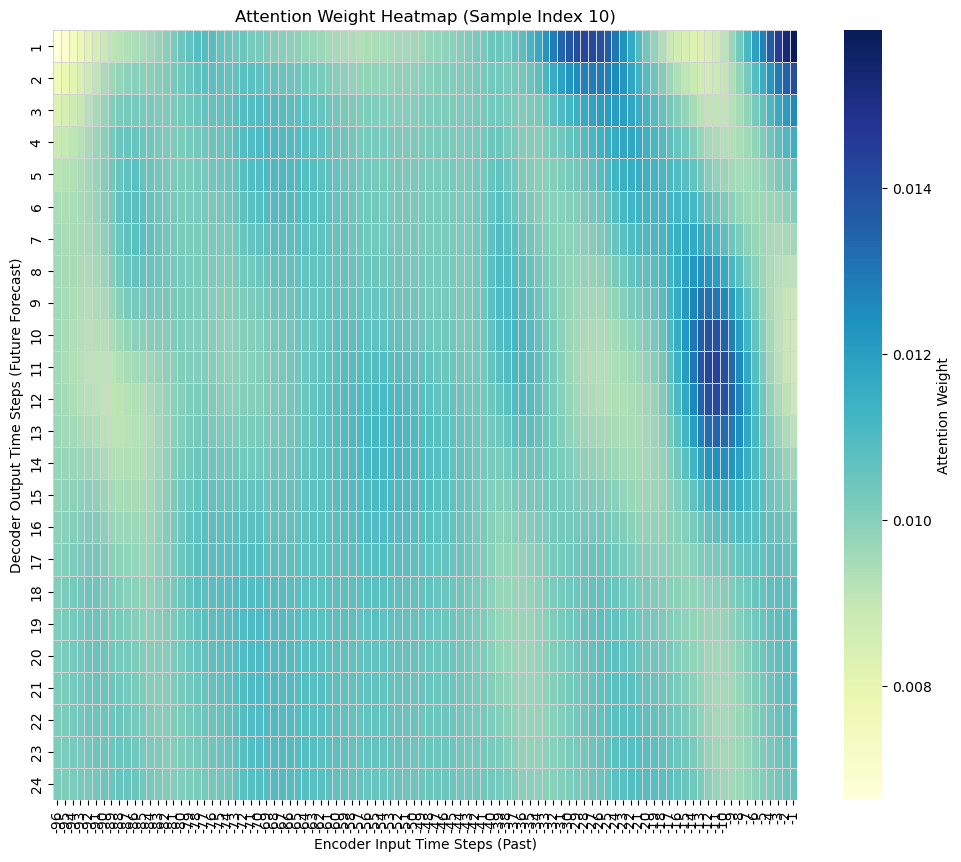

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select one sample from the test set (e.g., the 10th sample)
# You can change this index (0 to N-1) to inspect different forecasts.
sample_index = 10 
# att_weights_test shape is (N_samples, T_OUT, T_IN)
sample_weights = att_weights_test[sample_index] 

# Setup axis labels
# T_IN = 20 (Input steps -20 to -1)
encoder_steps = np.arange(-T_IN, 0)
# T_OUT = 24 (Output steps 1 to 24)
decoder_steps = np.arange(1, T_OUT + 1)

plt.figure(figsize=(12, 10))
sns.heatmap(
    sample_weights,
    xticklabels=encoder_steps,
    yticklabels=decoder_steps,
    cmap="YlGnBu",
    cbar_kws={'label': 'Attention Weight'},
    linewidths=.5,
    linecolor='lightgray'
)

plt.title(f'Attention Weight Heatmap (Sample Index {sample_index})')
plt.xlabel('Encoder Input Time Steps (Past)')
plt.ylabel('Decoder Output Time Steps (Future Forecast)')
plt.show()

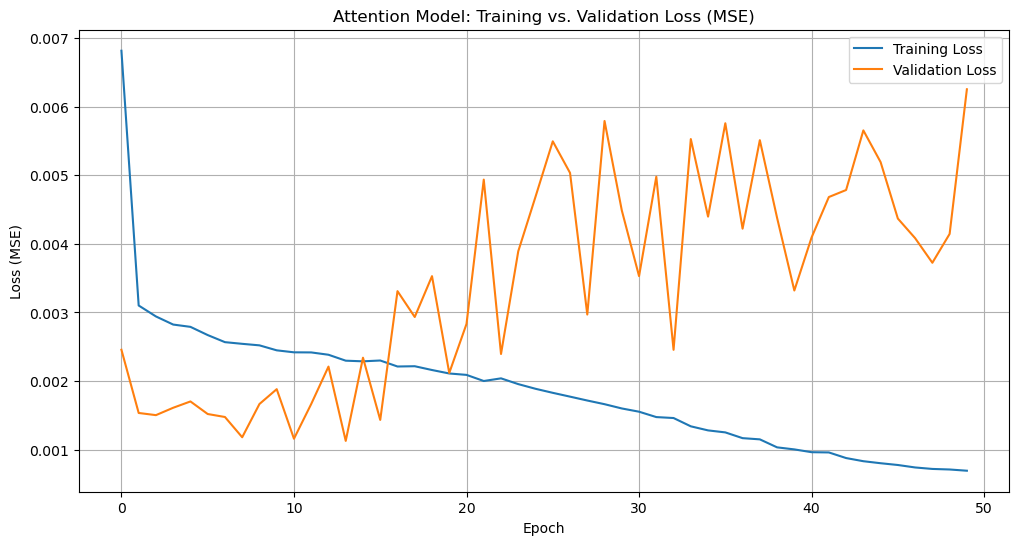

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(attention_history.history['loss'], label='Training Loss')
plt.plot(attention_history.history['val_loss'], label='Validation Loss')
plt.title('Attention Model: Training vs. Validation Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

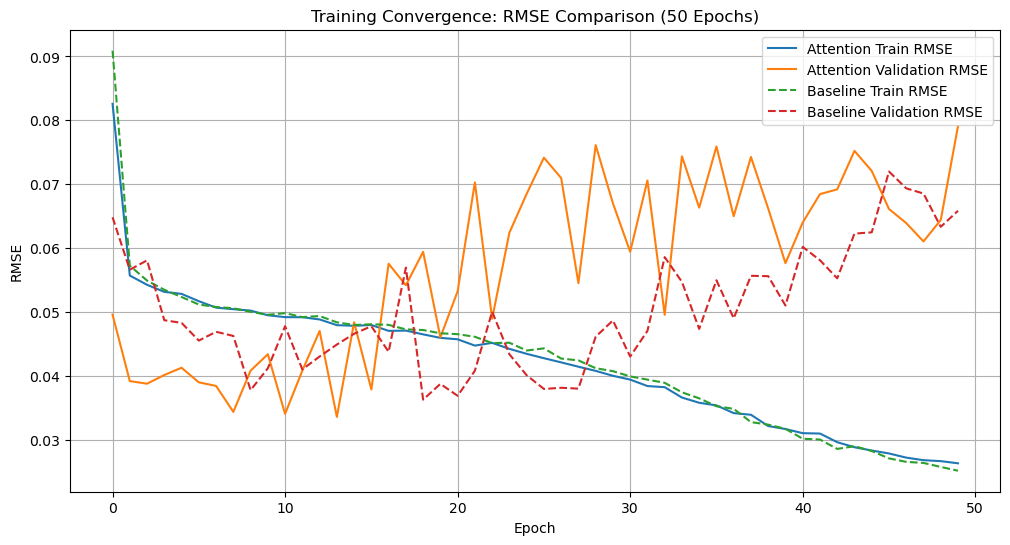

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(attention_history.history['prediction_output_rmse'], label='Attention Train RMSE')
plt.plot(attention_history.history['val_prediction_output_rmse'], label='Attention Validation RMSE')
plt.plot(baseline_history.history['rmse'], label='Baseline Train RMSE', linestyle='--')
plt.plot(baseline_history.history['val_rmse'], label='Baseline Validation RMSE', linestyle='--')
plt.title('Training Convergence: RMSE Comparison (50 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()

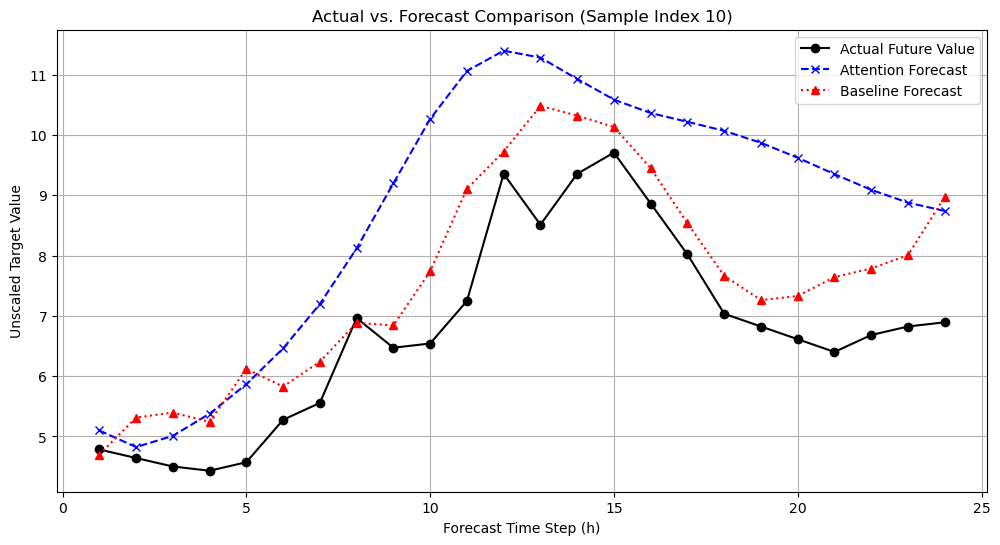

In [21]:
# NOTE: This requires base_pred_inv and Y_test_inv from the Evaluation Block to be in memory.

import matplotlib.pyplot as plt

# Select the same sample index used for the heatmap, e.g., index 10
sample_index = 10 
# T_OUT (Forecast Horizon) must be defined globally

# Extract data for the selected sample (T_OUT, 1) -> (T_OUT,)
actual_data = Y_test_inv[sample_index].flatten()
att_forecast = att_pred_inv[sample_index].flatten()
base_forecast = base_pred_inv[sample_index].flatten()
time_steps = range(1, T_OUT + 1)

plt.figure(figsize=(12, 6))
plt.plot(time_steps, actual_data, marker='o', label='Actual Future Value', color='black')
plt.plot(time_steps, att_forecast, marker='x', label='Attention Forecast', color='blue', linestyle='--')
plt.plot(time_steps, base_forecast, marker='^', label='Baseline Forecast', color='red', linestyle=':')
plt.title(f'Actual vs. Forecast Comparison (Sample Index {sample_index})')
plt.xlabel('Forecast Time Step (h)')
plt.ylabel('Unscaled Target Value')
plt.legend()
plt.grid(True)
plt.show()